<a href="https://colab.research.google.com/github/samrudhimadane6-creator/Customer-Segmentation/blob/main/Sales_%26_Revenue_Analysis_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas matplotlib plotly openpyxl

In [2]:
import pandas as pd

data = {
    "Date": [
        "2026-01-05", "2026-01-12", "2026-01-20",
        "2026-02-03", "2026-02-15", "2026-02-25",
        "2026-03-05", "2026-03-18", "2026-03-28",
        "2026-04-10", "2026-04-20", "2026-04-30"
    ],
    "Product": [
        "Laptop", "Mobile", "Headphones",
        "Laptop", "Tablet", "Mobile",
        "Headphones", "Laptop", "Tablet",
        "Mobile", "Laptop", "Headphones"
    ],
    "Category": [
        "Electronics", "Electronics", "Accessories",
        "Electronics", "Electronics", "Electronics",
        "Accessories", "Electronics", "Electronics",
        "Electronics", "Electronics", "Accessories"
    ],
    "Quantity": [2, 5, 10, 3, 4, 6, 12, 2, 5, 7, 4, 15],
    "Price": [60000, 25000, 1500, 60000, 30000, 25000,
              1500, 60000, 30000, 25000, 60000, 1500]
}

df = pd.DataFrame(data)

df["Date"] = pd.to_datetime(df["Date"])

df["Revenue"] = df["Quantity"] * df["Price"]

df

,Date,Product,Category,Quantity,Price,Revenue
0,2026-01-05,Laptop,Electronics,2,60000,120000
1,2026-01-12,Mobile,Electronics,5,25000,125000
2,2026-01-20,Headphones,Accessories,10,1500,15000
3,2026-02-03,Laptop,Electronics,3,60000,180000
4,2026-02-15,Tablet,Electronics,4,30000,120000
5,2026-02-25,Mobile,Electronics,6,25000,150000
6,2026-03-05,Headphones,Accessories,12,1500,18000
7,2026-03-18,Laptop,Electronics,2,60000,120000
8,2026-03-28,Tablet,Electronics,5,30000,150000
9,2026-04-10,Mobile,Electronics,7,25000,175000


In [3]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

df.info()

Number of Rows: 12
Number of Columns: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      12 non-null     datetime64[ns]
 1   Product   12 non-null     object        
 2   Category  12 non-null     object        
 3   Quantity  12 non-null     int64         
 4   Price     12 non-null     int64         
 5   Revenue   12 non-null     int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 708.0+ bytes


In [4]:
df.describe()

,Date,Quantity,Price,Revenue
count,12,12.000000,12.000000,12.000000
mean,2026-03-01 22:00:00,6.250000,31625.000000,119625.000000
min,2026-01-05 00:00:00,2.000000,1500.000000,15000.000000
25%,2026-01-30 12:00:00,3.750000,19125.000000,95625.000000
50%,2026-03-01 00:00:00,5.000000,27500.000000,122500.000000
75%,2026-03-31 06:00:00,7.750000,60000.000000,156250.000000
max,2026-04-30 00:00:00,15.000000,60000.000000,240000.000000
std,NaN,4.092676,23510.273383,69924.350356


In [5]:
total_revenue = df["Revenue"].sum()

print("Total Revenue: ₹", total_revenue)

Total Revenue: ₹ 1435500


In [6]:
total_orders = len(df)

print("Total Orders:", total_orders)

Total Orders: 12


In [7]:
top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)

print(top_products)

Product
Laptop        660000
Mobile        450000
Tablet        270000
Headphones     55500
Name: Revenue, dtype: int64


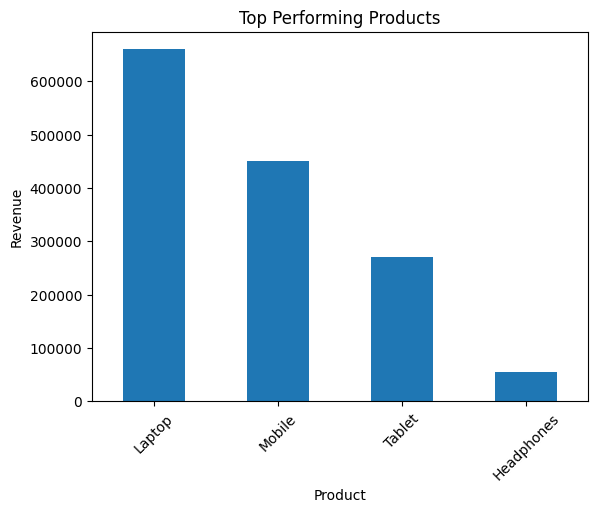

In [8]:
import matplotlib.pyplot as plt

top_products.plot(kind="bar")

plt.title("Top Performing Products")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [9]:
df["Month"] = df["Date"].dt.to_period("M")

monthly_revenue = df.groupby("Month")["Revenue"].sum()

print(monthly_revenue)

Month
2026-01    260000
2026-02    450000
2026-03    288000
2026-04    437500
Freq: M, Name: Revenue, dtype: int64


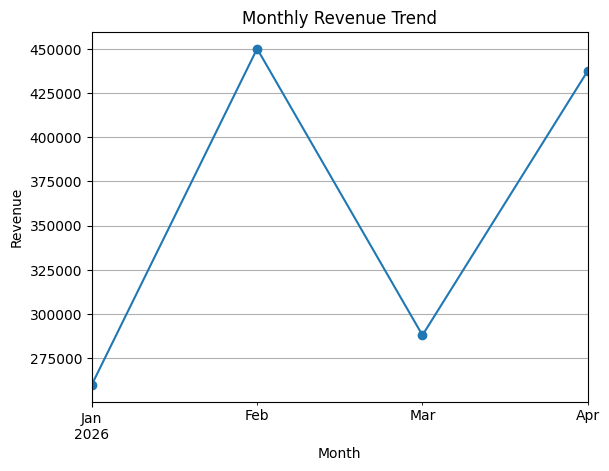

In [10]:
monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [11]:
category_sales = df.groupby("Category")["Revenue"].sum()

print(category_sales)

Category
Accessories      55500
Electronics    1380000
Name: Revenue, dtype: int64


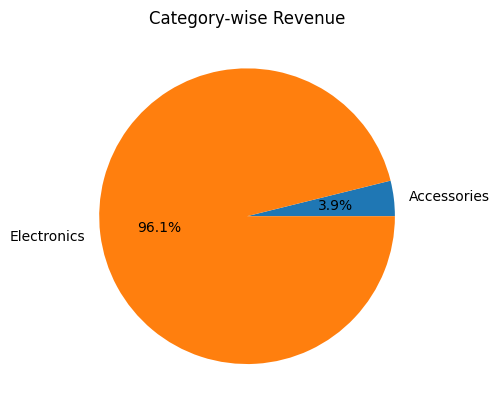

In [12]:
category_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Category-wise Revenue")
plt.ylabel("")
plt.show()

In [13]:
import plotly.express as px

fig = px.bar(
    df,
    x="Product",
    y="Revenue",
    color="Category",
    title="Product-wise Revenue"
)

fig.show()

In [14]:
monthly_df = df.groupby("Month", as_index=False)["Revenue"].sum()

monthly_df["Month"] = monthly_df["Month"].astype(str)

fig = px.line(
    monthly_df,
    x="Month",
    y="Revenue",
    markers=True,
    title="Monthly Revenue Trend"
)

fig.show()

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

total_sales = df["Quantity"].sum()
total_revenue = df["Revenue"].sum()
total_orders = len(df)

print("================================")
print("     SALES & REVENUE DASHBOARD")
print("================================")

print("Total Sales    :", total_sales)
print("Total Revenue  : ₹", total_revenue)
print("Total Orders   :", total_orders)

print("\nTop Products:")
print(top_products)

     SALES & REVENUE DASHBOARD
Total Sales    : 75
Total Revenue  : ₹ 1435500
Total Orders   : 12

Top Products:
Product
Laptop        660000
Mobile        450000
Tablet        270000
Headphones     55500
Name: Revenue, dtype: int64


In [16]:
fig = px.bar(
    top_products.reset_index(),
    x="Product",
    y="Revenue",
    title="Top Performing Products"
)

fig.show()

In [17]:
fig = px.pie(
    category_sales.reset_index(),
    names="Category",
    values="Revenue",
    title="Revenue by Category"
)

fig.show()

In [18]:
fig = px.line(
    monthly_df,
    x="Month",
    y="Revenue",
    markers=True,
    title="Monthly Revenue Trend"
)

fig.show()

In [19]:
fig = px.bar(
    df,
    x="Product",
    y="Revenue",
    color="Category",
    facet_col="Category",
    title="Category-wise Product Revenue"
)

fig.show()

In [21]:
# Monthly Revenue Trend

monthly_df = df.groupby("Month", as_index=False)["Revenue"].sum()

monthly_df["Month"] = monthly_df["Month"].astype(str)

fig = px.line(
    monthly_df,
    x="Month",
    y="Revenue",
    markers=True,
    title="Monthly Revenue Trend"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Revenue"
)

fig.show()

In [22]:
# KPI Calculations

total_sales = df["Quantity"].sum()
total_revenue = df["Revenue"].sum()
total_orders = len(df)

print("========== SALES & REVENUE KPI ==========")
print("Total Sales   :", total_sales)
print("Total Revenue : ₹", total_revenue)
print("Total Orders  :", total_orders)

========== SALES & REVENUE KPI ==========
Total Sales   : 75
Total Revenue : ₹ 1435500
Total Orders  : 12


In [23]:
# Top Performing Product

top_product = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Top Performing Products:")
print(top_product)

print("\nBest Product:", top_product.idxmax())
print("Highest Revenue: ₹", top_product.max())

Top Performing Products:
Product
Laptop        660000
Mobile        450000
Tablet        270000
Headphones     55500
Name: Revenue, dtype: int64

Best Product: Laptop
Highest Revenue: ₹ 660000


In [24]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# KPI values
total_sales = df["Quantity"].sum()
total_revenue = df["Revenue"].sum()
total_orders = len(df)

# Product revenue
product_revenue = (
    df.groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

# Category revenue
category_revenue = df.groupby("Category")["Revenue"].sum()

# Monthly revenue
monthly_revenue = df.groupby("Month")["Revenue"].sum()

# Convert month to string
monthly_revenue.index = monthly_revenue.index.astype(str)

# Create dashboard
fig = make_subplots(
    rows=3,
    cols=2,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "bar"}],
        [{"type": "xy"}, {"type": "pie"}]
    ],
    subplot_titles=(
        "Total Sales",
        "Total Revenue",
        "Total Orders",
        "Top Performing Products",
        "Monthly Revenue Trend",
        "Revenue by Category"
    )
)

# KPI 1 - Total Sales
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_sales,
        number={"valueformat": ","}
    ),
    row=1,
    col=1
)

# KPI 2 - Total Revenue
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_revenue,
        number={"prefix": "₹", "valueformat": ","}
    ),
    row=1,
    col=2
)

# KPI 3 - Total Orders
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_orders,
        number={"valueformat": ","}
    ),
    row=2,
    col=1
)

# Top Products Bar Chart
fig.add_trace(
    go.Bar(
        x=product_revenue.index,
        y=product_revenue.values,
        name="Revenue"
    ),
    row=2,
    col=2
)

# Monthly Revenue Line Chart
fig.add_trace(
    go.Scatter(
        x=monthly_revenue.index,
        y=monthly_revenue.values,
        mode="lines+markers",
        name="Monthly Revenue"
    ),
    row=3,
    col=1
)

# Category Pie Chart
fig.add_trace(
    go.Pie(
        labels=category_revenue.index,
        values=category_revenue.values,
        name="Category"
    ),
    row=3,
    col=2
)

# Dashboard title
fig.update_layout(
    title_text="Sales & Revenue Analysis Dashboard",
    height=1000,
    showlegend=False
)

fig.show()

In [25]:
import plotly.express as px

fig = px.bar(
    df,
    x="Product",
    y="Revenue",
    color="Category",
    title="Interactive Sales Analysis",
    hover_data=["Quantity", "Price", "Revenue"]
)

fig.update_layout(
    xaxis_title="Product",
    yaxis_title="Revenue",
    title_x=0.5
)

fig.show()

In [26]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.express as px

# Product dropdown
product_filter = widgets.Dropdown(
    options=["All"] + sorted(df["Product"].unique().tolist()),
    value="All",
    description="Product:"
)

# Category dropdown
category_filter = widgets.Dropdown(
    options=["All"] + sorted(df["Category"].unique().tolist()),
    value="All",
    description="Category:"
)

output = widgets.Output()

def update_dashboard(change=None):
    with output:
        clear_output(wait=True)

        filtered_df = df.copy()

        # Product filter
        if product_filter.value != "All":
            filtered_df = filtered_df[
                filtered_df["Product"] == product_filter.value
            ]

        # Category filter
        if category_filter.value != "All":
            filtered_df = filtered_df[
                filtered_df["Category"] == category_filter.value
            ]

        # Display KPIs
        print("========== FILTERED SALES ANALYSIS ==========")
        print("Total Sales   :", filtered_df["Quantity"].sum())
        print("Total Revenue : ₹", filtered_df["Revenue"].sum())
        print("Total Orders  :", len(filtered_df))

        # Chart
        if len(filtered_df) > 0:
            fig = px.bar(
                filtered_df,
                x="Product",
                y="Revenue",
                color="Category",
                title="Filtered Product Revenue",
                hover_data=["Quantity", "Price", "Revenue"]
            )

            fig.update_layout(
                xaxis_title="Product",
                yaxis_title="Revenue",
                title_x=0.5
            )

            fig.show()
        else:
            print("No data available for selected filters.")

# Connect filters
product_filter.observe(update_dashboard, names="value")
category_filter.observe(update_dashboard, names="value")

# Display filters
display(product_filter, category_filter, output)

# Initial display
update_dashboard()

Dropdown(description='Product:', options=('All', 'Headphones', 'Laptop', 'Mobile', 'Tablet'), value='All')

Dropdown(description='Category:', options=('All', 'Accessories', 'Electronics'), value='All')

Output()